In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
from xgboost import XGBClassifier
import shap
import joblib

print("✅ Imports OK")

✅ Imports OK


In [5]:
df = pd.read_csv("D:/churn-prediction-project/data/processed/churn_features.csv")

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisation (utile pour la régression logistique)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"Taux de churn train : {y_train.mean()*100:.1f}%")

Train : (5625, 25) | Test : (1407, 25)
Taux de churn train : 26.6%


In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=200, learning_rate=0.05,
                                         use_label_encoder=False,
                                         eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == "Logistic Regression" else X_train
    X_te = X_test_sc  if name == "Logistic Regression" else X_test
    
    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    auc = roc_auc_score(y_test, y_proba)
    cv  = cross_val_score(model, X_tr, y_train, cv=5,
                          scoring='roc_auc').mean()
    results[name] = {'model': model, 'auc': auc, 'cv_auc': cv,
                     'y_pred': y_pred, 'y_proba': y_proba}
    print(f"{name:25s} → AUC test : {auc:.4f} | AUC CV : {cv:.4f}")

Logistic Regression       → AUC test : 0.8371 | AUC CV : 0.8482
Random Forest             → AUC test : 0.8174 | AUC CV : 0.8312
XGBoost                   → AUC test : 0.8282 | AUC CV : 0.8376


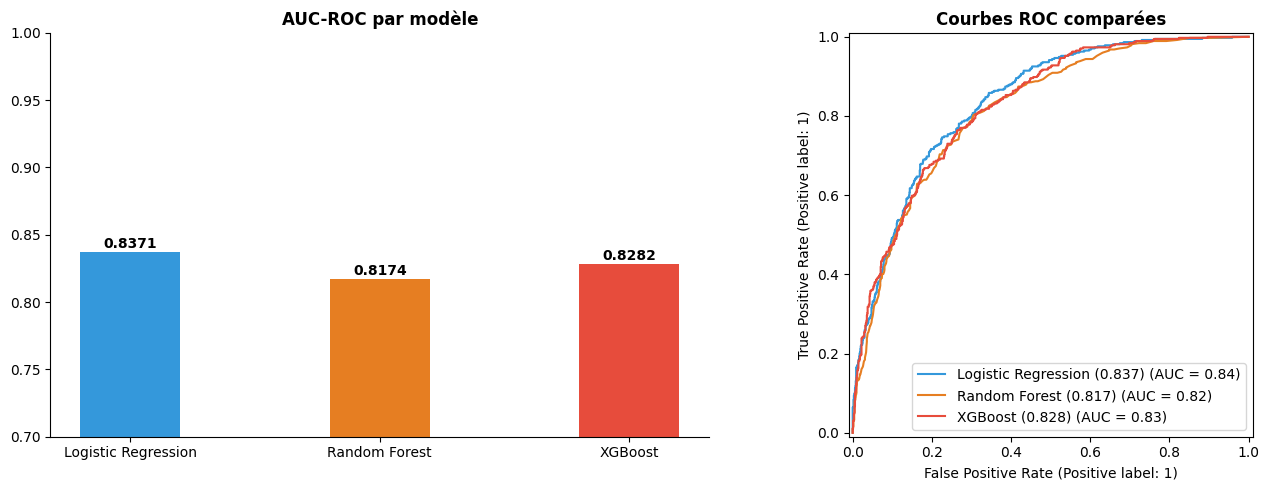

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot AUC
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
colors = ['#3498db', '#e67e22', '#e74c3c']
axes[0].bar(names, aucs, color=colors, width=0.4)
axes[0].set_ylim(0.7, 1.0)
for i, v in enumerate(aucs):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontweight='bold')
axes[0].set_title('AUC-ROC par modèle', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Courbes ROC
for name, color in zip(names, colors):
    RocCurveDisplay.from_predictions(
        y_test, results[name]['y_proba'],
        name=f"{name} ({results[name]['auc']:.3f})",
        ax=axes[1], color=color)
axes[1].set_title('Courbes ROC comparées', fontweight='bold')

plt.tight_layout()
plt.savefig('D:/churn-prediction-project/reports/figures/06_model_comparison.png', dpi=150)
plt.show()

🏆 Meilleur modèle : Logistic Regression (AUC = 0.8371)

              precision    recall  f1-score   support

      Fidèle       0.84      0.88      0.86      1033
     Churner       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.73      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



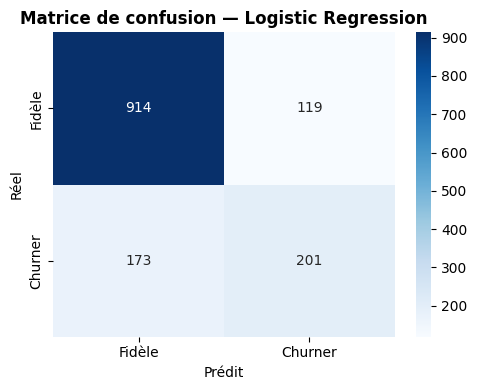

In [12]:
best_name = max(results, key=lambda n: results[n]['auc'])
best = results[best_name]
print(f"🏆 Meilleur modèle : {best_name} (AUC = {best['auc']:.4f})\n")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Fidèle', 'Churner']))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Fidèle', 'Churner'],
            yticklabels=['Fidèle', 'Churner'])
ax.set_title(f'Matrice de confusion — {best_name}', fontweight='bold')
ax.set_ylabel('Réel')
ax.set_xlabel('Prédit')
plt.tight_layout()
plt.savefig('D:/churn-prediction-project/reports/figures/07_confusion_matrix.png', dpi=150)
plt.show()

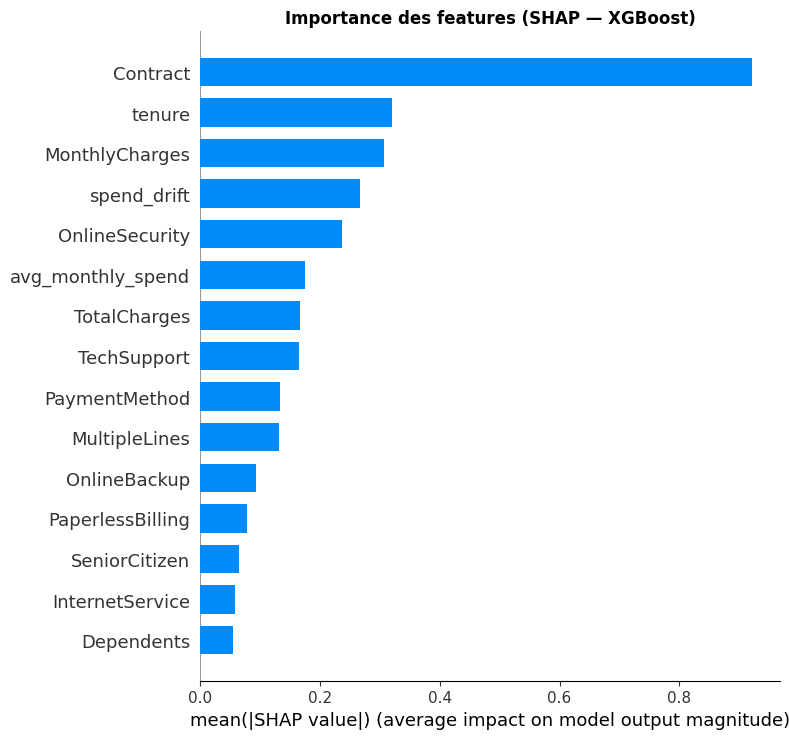

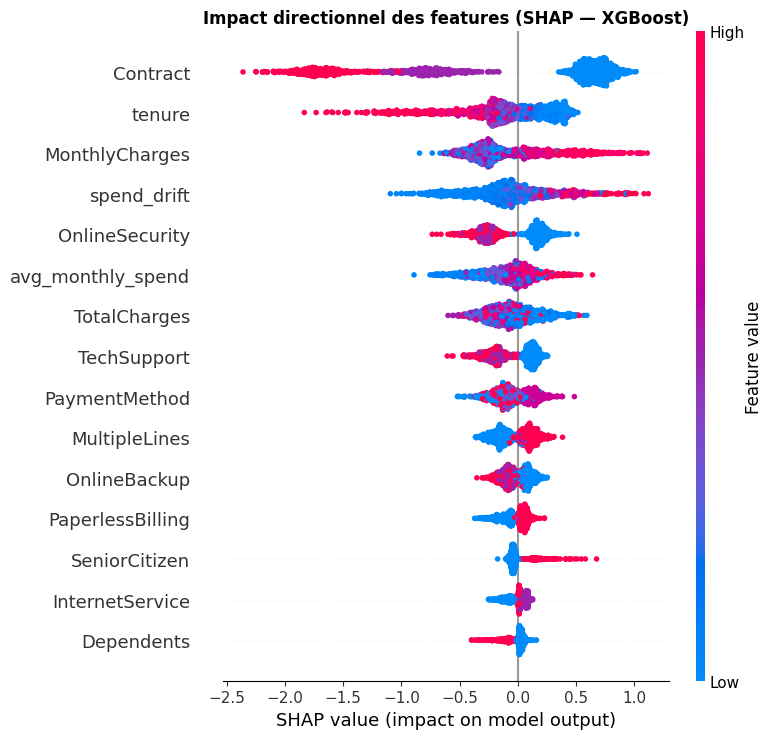

In [20]:
# On force XGBoost pour SHAP (TreeExplainer ne supporte pas LogisticRegression)
xgb_model = results["XGBoost"]["model"]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot — importance globale
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar",
                  show=False, max_display=15)
plt.title("Importance des features (SHAP — XGBoost)", fontweight='bold')
plt.tight_layout()
plt.savefig('D:/churn-prediction-project/reports/figures/08_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm — impact directionnel
plt.figure()
shap.summary_plot(shap_values, X_test, show=False, max_display=15)
plt.title("Impact directionnel des features (SHAP — XGBoost)", fontweight='bold')
plt.tight_layout()
plt.savefig('D:/churn-prediction-project/reports/figures/09_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
joblib.dump(best_model, 'D:/churn-prediction-project/models/best_model.pkl')
joblib.dump(scaler,     'D:/churn-prediction-project/models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'D:/churn-prediction-project/models/feature_names.pkl')

print(f"✅ Modèle '{best_name}' sauvegardé dans models/")
print(f"   AUC final : {best['auc']:.4f}")

✅ Modèle 'Logistic Regression' sauvegardé dans models/
   AUC final : 0.8371


In [26]:
# Force la sauvegarde de XGBoost
xgb_model = results["XGBoost"]["model"]
joblib.dump(xgb_model, 'D:/churn-prediction-project/models/best_model.pkl')
joblib.dump(scaler,     'D:/churn-prediction-project/models/scaler.pkl')
joblib.dump(X.columns.tolist(), 'D:/churn-prediction-project/models/feature_names.pkl')
print("✅ XGBoost sauvegardé")

✅ XGBoost sauvegardé
